# Student Academic Performance Analysis
## this dataset includes data on students' academic success. Gender, race/ethnicity, parental education level, lunch type, test preparation course completion, weekly study time, and daily sleep duration are some of the variables that are included. 
## The purpose of this dataset is to assist educational research, statistical analysis, and machine learning applications that seek to comprehend the ways in which individual background and study habits influence academic achievement.

In [16]:
import sys
import sklearn
import numpy as np
import pandas as pd
import os 

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)


import tarfile
import urllib

# Get the data

In [17]:
student_performance_path = os.path.join("datasets", "student_performance")
def get_data(path_data = student_performance_path):
    cvs_path = os.path.join(path_data, "student_academic_performance.csv")
    return pd.read_csv(cvs_path)

student_performance = get_data()
student_performance.head()

,Student ID,Gender,Race/Ethnicity,Parental Education,Lunch Type,Test Preparation,Study Time per Week,Daily Sleep Duration,Math Score,Reading Score,Writing Score,School Type,Internet Access
0,1,female,group B,some college,standard,False,12.4,5.4,62.0,76.0,65.0,public,True
1,2,male,group D,high school,standard,False,18.3,5.1,74.0,73.0,76.0,public,NaN
2,3,male,group B,bachelor degree,free/reduced,True,11.8,7.8,71.0,83.0,91.0,public,False
3,4,male,group E,high school,standard,False,NaN,7.3,83.0,73.0,52.0,public,True
4,5,female,group C,bachelor degree,standard,True,12.9,6.3,41.0,NaN,81.0,public,True


In [18]:
student_performance.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student ID            7000 non-null   int64  
 1   Gender                7000 non-null   object 
 2   Race/Ethnicity        7000 non-null   object 
 3   Parental Education    6300 non-null   object 
 4   Lunch Type            6790 non-null   object 
 5   Test Preparation      7000 non-null   bool   
 6   Study Time per Week   6370 non-null   float64
 7   Daily Sleep Duration  6440 non-null   float64
 8   Math Score            7000 non-null   float64
 9   Reading Score         6510 non-null   float64
 10  Writing Score         6650 non-null   float64
 11  School Type           7000 non-null   object 
 12  Internet Access       6720 non-null   object 
dtypes: bool(1), float64(5), int64(1), object(6)
memory usage: 663.2+ KB


# Visualize data

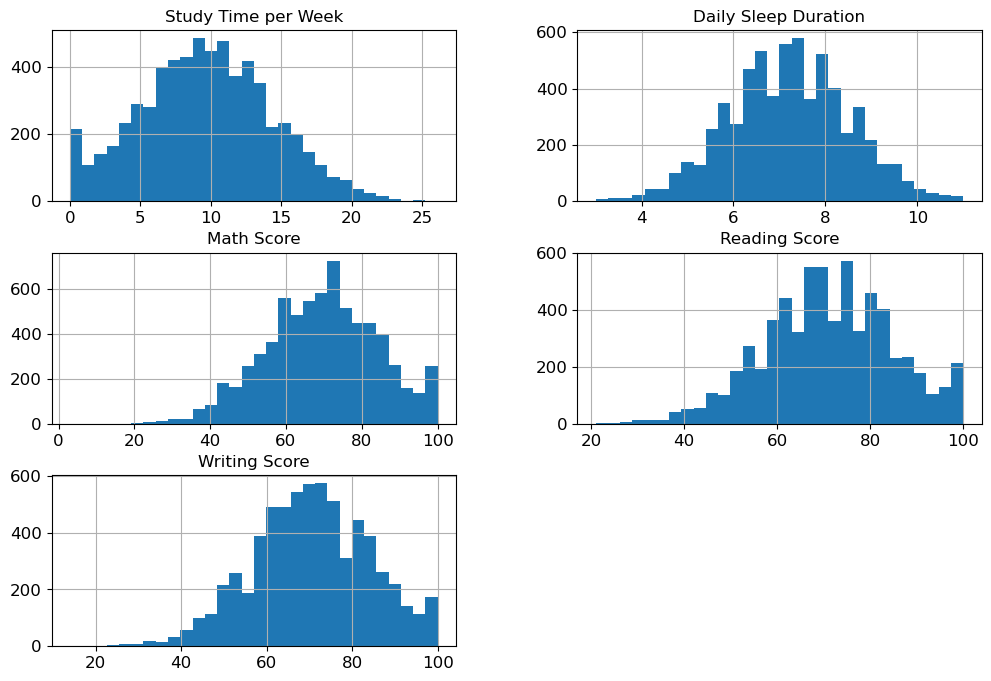

In [19]:
# lets look the raw data

# visualize numerical values

num_col = student_performance.select_dtypes(include='number').drop(columns=["Student ID"])
num_col.hist(bins = 30, figsize=(12,8))
plt.show()

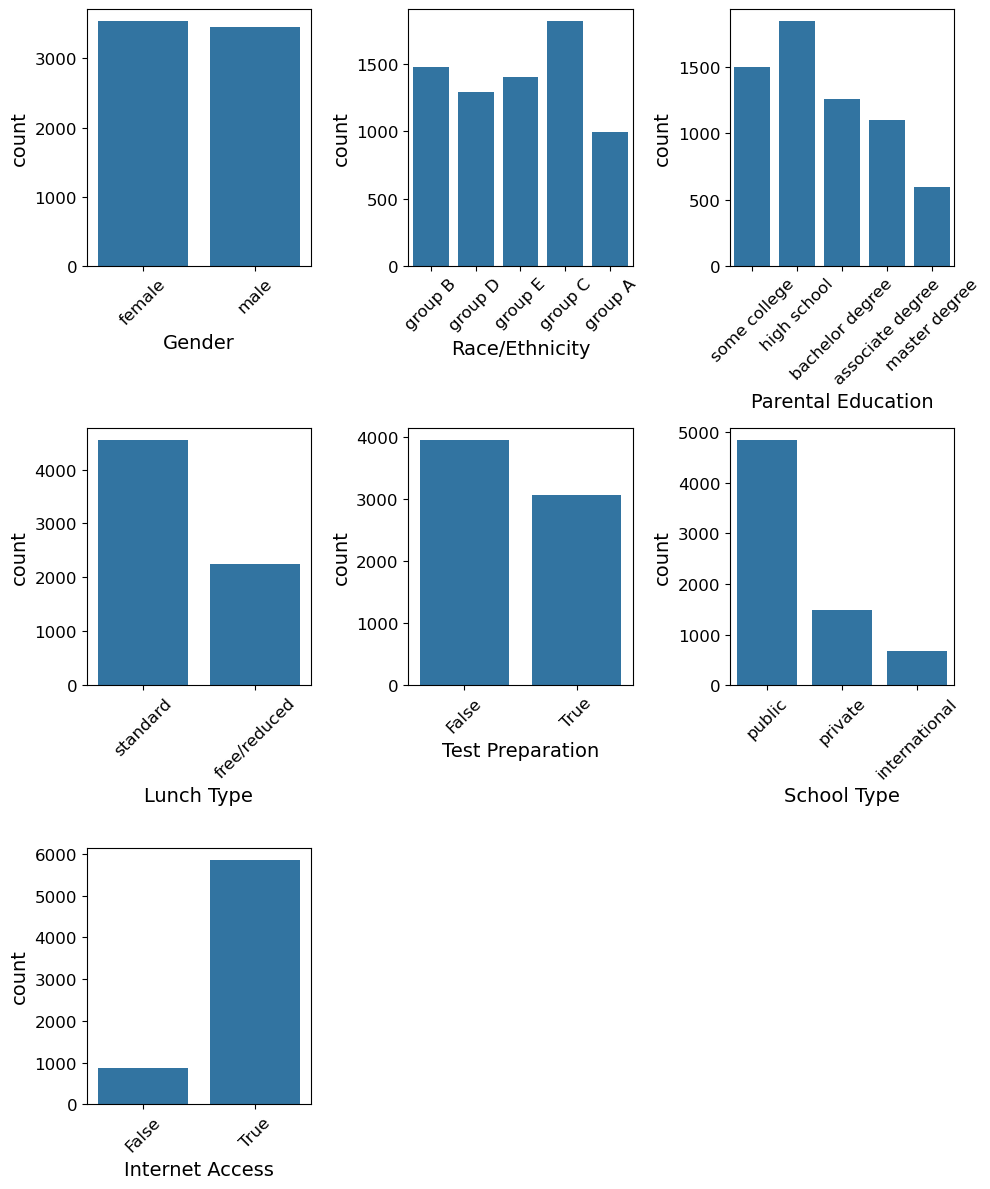

In [20]:
# visualize categorical values
import seaborn as sns
import math

cat_col = student_performance.select_dtypes(include=['object', 'category', 'bool'])
n_cols = 3
#how many plots per row
n_rows = math.ceil(len(cat_col.columns)/n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4*n_rows))
axes = axes.flatten()
for i, col in enumerate(cat_col.columns):
    sns.countplot(data=cat_col, x=col, ax=axes[i])
    axes[i].tick_params(axis='x', rotation=45)

# remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()
    


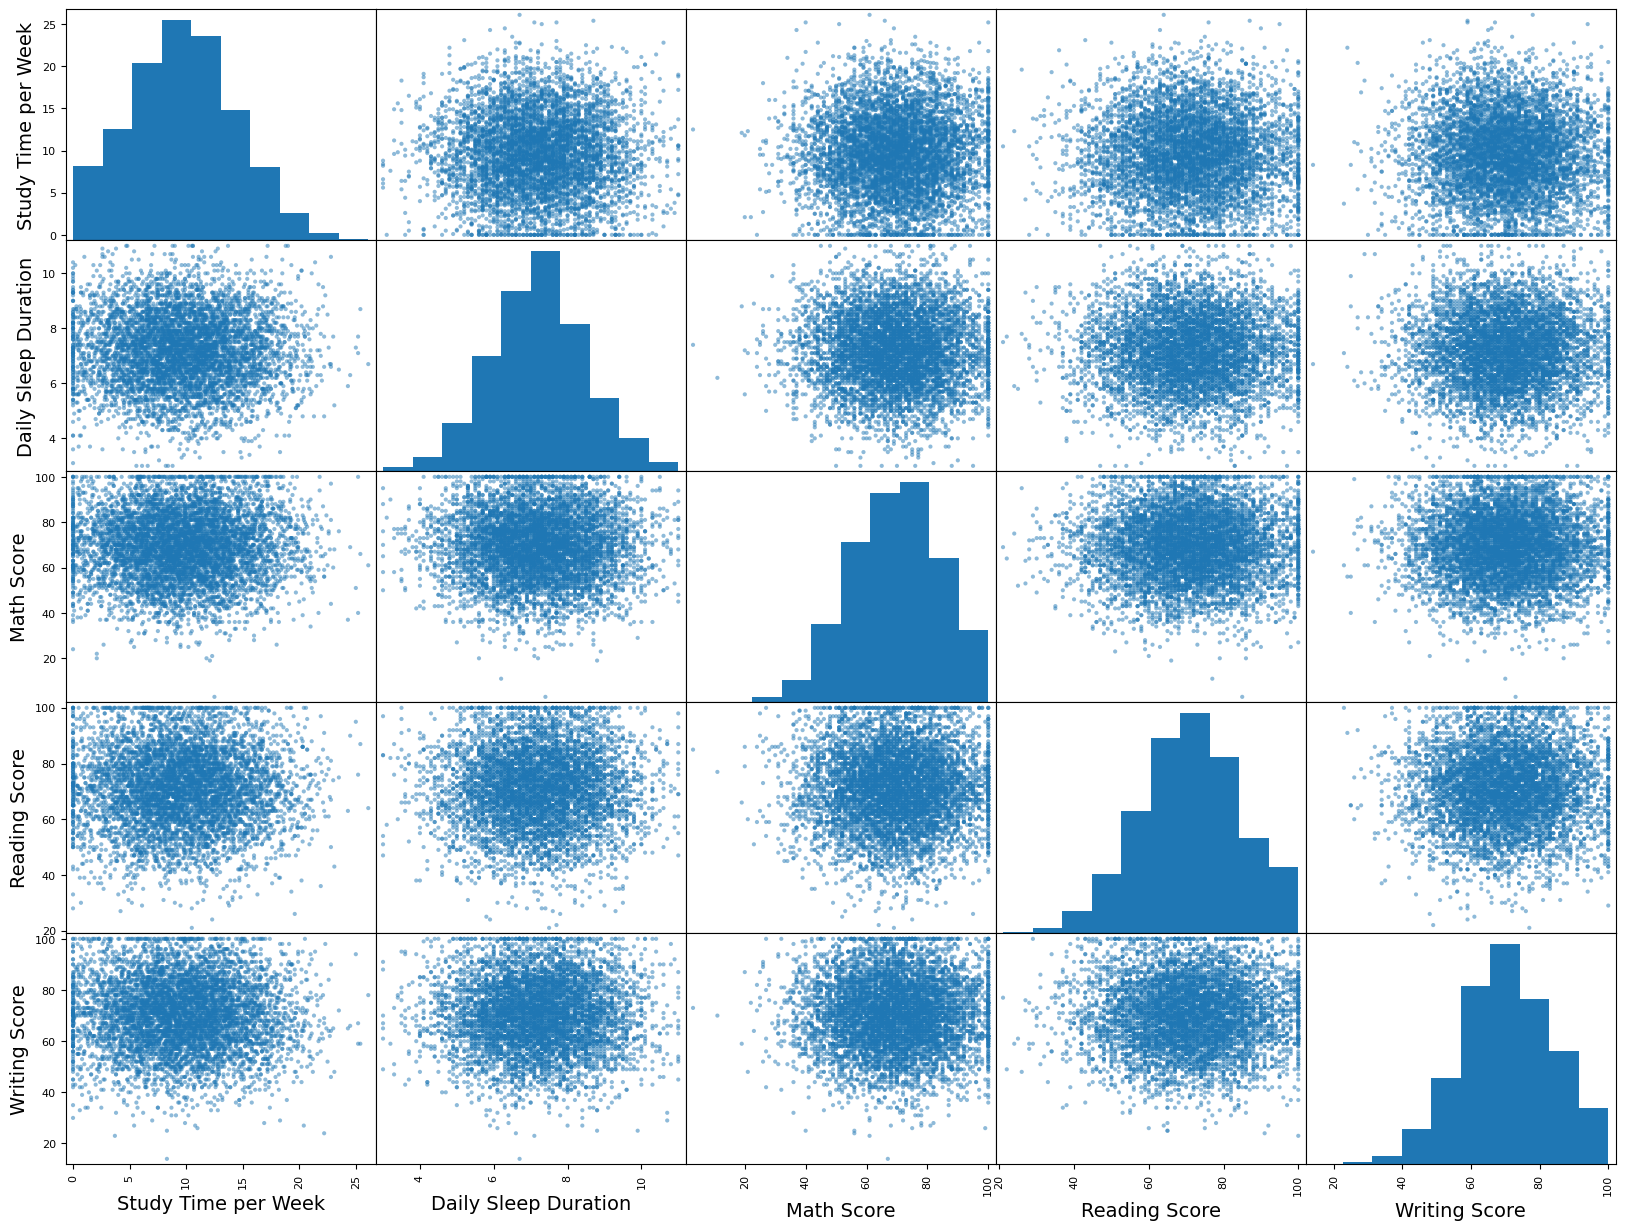

In [21]:
# lets look into the correlation for numerical features

from pandas.plotting import scatter_matrix

scatter_matrix(num_col, figsize=(20, 15))
plt.show()

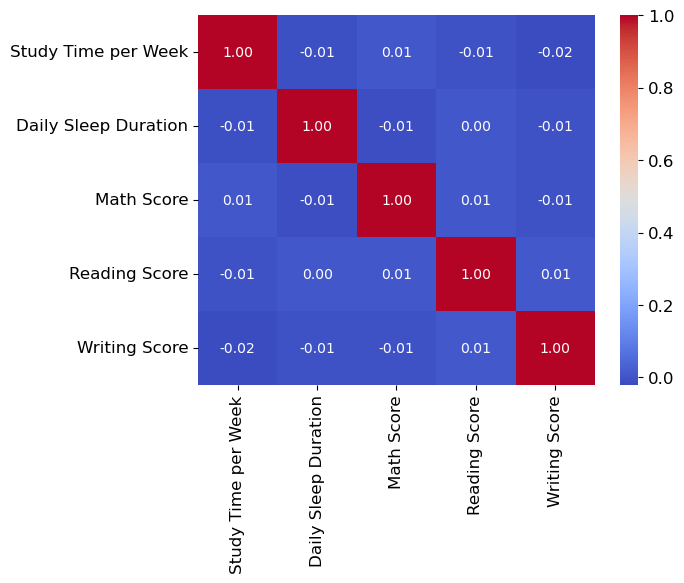

In [22]:
# get the correlation using standard values

sns.heatmap(num_col.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

# Prepare the Data for ML 

In [23]:
# null values
missing = student_performance.isnull().sum()
for i, col in enumerate(student_performance.columns):
    missing_per_column = student_performance[col].isnull().sum()
    total_entries = len(student_performance[col])
    print(f"Fraction of null values in {col}: {missing_per_column/total_entries*100: 2f}%")
    

Fraction of null values in Student ID:  0.000000%
Fraction of null values in Gender:  0.000000%
Fraction of null values in Race/Ethnicity:  0.000000%
Fraction of null values in Parental Education:  10.000000%
Fraction of null values in Lunch Type:  3.000000%
Fraction of null values in Test Preparation:  0.000000%
Fraction of null values in Study Time per Week:  9.000000%
Fraction of null values in Daily Sleep Duration:  8.000000%
Fraction of null values in Math Score:  0.000000%
Fraction of null values in Reading Score:  7.000000%
Fraction of null values in Writing Score:  5.000000%
Fraction of null values in School Type:  0.000000%
Fraction of null values in Internet Access:  4.000000%


In [24]:
# data duplicates 
duplicates = student_performance.duplicated().sum()
print(duplicates)

0


## Imputing (method 1)

In [25]:
# get the columns with missing values
missing_cols = missing[missing > 0].index.tolist()


# Start with categorical values: imput with the most frequent variable (mode) 
clean_student_performance = student_performance.copy()

cat_list = ['Parental Education', 'Lunch Type', 'Internet Access']

for col_name in cat_list:
    mode_val = clean_student_performance[col_name].mode()[0]
    clean_student_performance[col_name] = clean_student_performance[col_name].fillna(mode_val)


# Now with numerical values with the mean 

num_list = ['Study Time per Week', 'Daily Sleep Duration', 'Reading Score', 'Writing Score']

for col in num_list:
    mean_val = clean_student_performance[col].mean()
    clean_student_performance[col] = clean_student_performance[col].fillna(mean_val)

print(f"Missing after imputing method 1 : \n {clean_student_performance.isnull().sum()}")



Missing after imputing method 1 : 
 Student ID              0
Gender                  0
Race/Ethnicity          0
Parental Education      0
Lunch Type              0
Test Preparation        0
Study Time per Week     0
Daily Sleep Duration    0
Math Score              0
Reading Score           0
Writing Score           0
School Type             0
Internet Access         0
dtype: int64


## Imputing (method 2)
### The resulting dataframe will be used to train the model

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import FunctionTransformer

num_attributes = list(num_col)
cat_attributes = list(cat_col)

# lets start with the numerical pipeline 

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

full_pipeline = ColumnTransformer([
        ("num", num_pipeline, num_attributes),
        ("cat", OneHotEncoder(), cat_attributes),
    ])

student_performance_tr = full_pipeline.fit_transform(student_performance)

student_performance_tr_df = pd.DataFrame(
    student_performance_tr,
    columns=full_pipeline.get_feature_names_out()
)
print(f"Missing after imputing method 2 : \n {student_performance_tr_df.isnull().sum()}")

Missing after imputing method 2 : 
 num__Study Time per Week                    0
num__Daily Sleep Duration                   0
num__Math Score                             0
num__Reading Score                          0
num__Writing Score                          0
cat__Gender_female                          0
cat__Gender_male                            0
cat__Race/Ethnicity_group A                 0
cat__Race/Ethnicity_group B                 0
cat__Race/Ethnicity_group C                 0
cat__Race/Ethnicity_group D                 0
cat__Race/Ethnicity_group E                 0
cat__Parental Education_associate degree    0
cat__Parental Education_bachelor degree     0
cat__Parental Education_high school         0
cat__Parental Education_master degree       0
cat__Parental Education_some college        0
cat__Parental Education_nan                 0
cat__Lunch Type_free/reduced                0
cat__Lunch Type_standard                    0
cat__Lunch Type_nan                         

# Processing data

In [27]:
# average score 

clean_student_performance["Avg Score"] = (clean_student_performance["Math Score"] + clean_student_performance["Reading Score"] + clean_student_performance["Writing Score"])/3

## Categorical variables

/tmp/ipykernel_6474/2145341218.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=score, x=col, y="Avg Score", palette="pastel", edgecolor="black", ax=axes[i])
/tmp/ipykernel_6474/2145341218.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=score, x=col, y="Avg Score", palette="pastel", edgecolor="black", ax=axes[i])
/tmp/ipykernel_6474/2145341218.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=score, x=col, y="Avg Score", palette="pastel", edgecolor="black", ax=axes[i])
/tmp/ipykernel_6474/2145341218.py:7: FutureWarnin

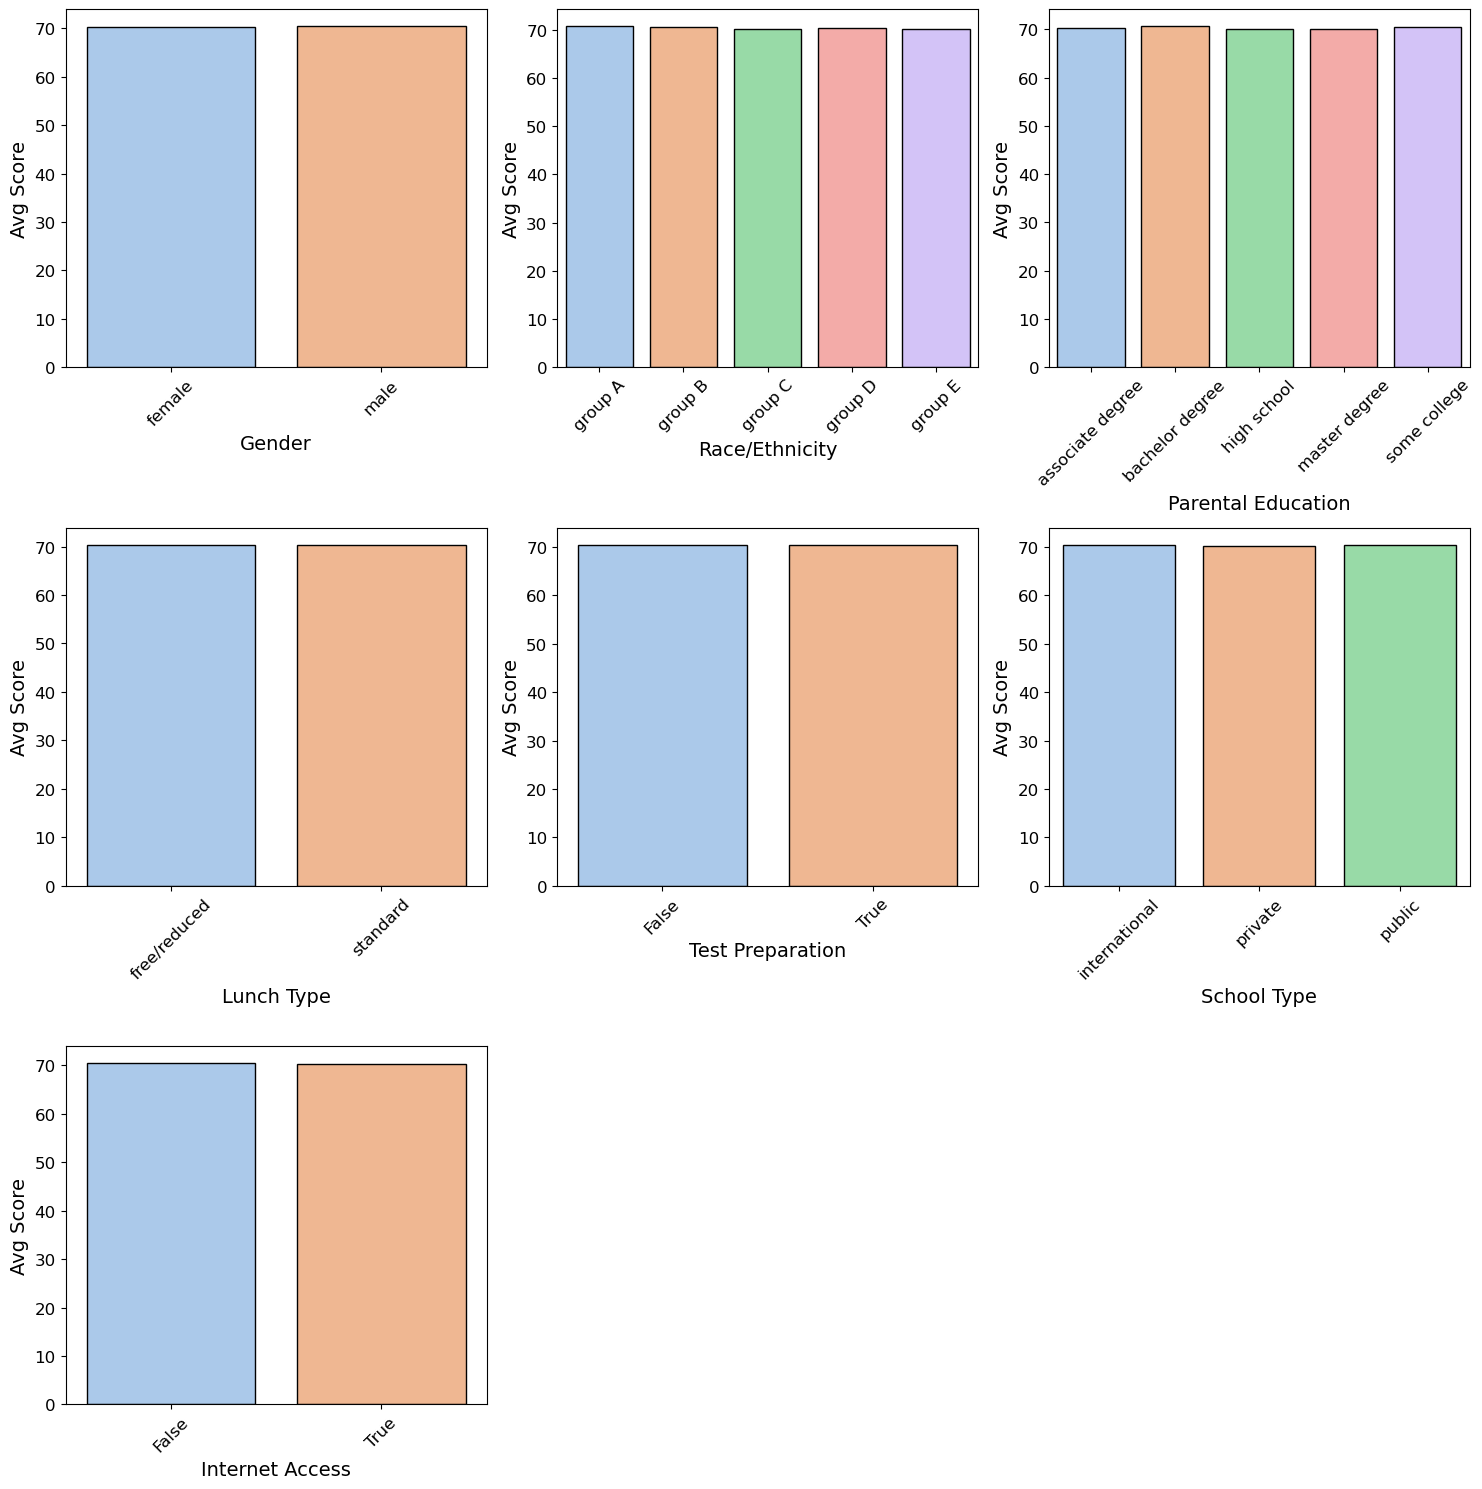

In [28]:
# average score per each categorical value
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_col.columns):
    score = clean_student_performance.groupby(col)["Avg Score"].mean().reset_index()
    sns.barplot(data=score, x=col, y="Avg Score", palette="pastel", edgecolor="black", ax=axes[i])
    axes[i].tick_params(axis='x', rotation=45)

# remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

## Numerical Variables

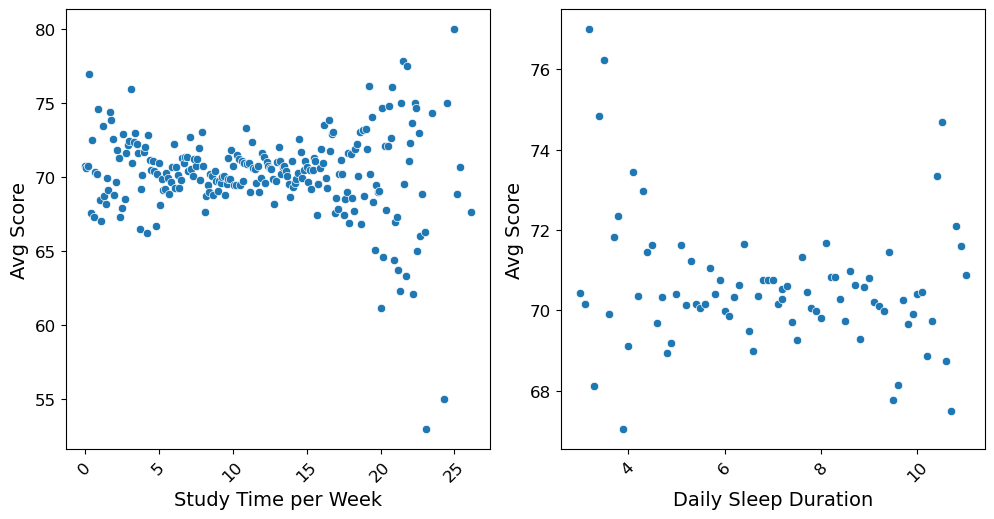

In [29]:
# Relating each numerical class with the average score

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()
col_no_score = ['Study Time per Week', 'Daily Sleep Duration']
for i, col in enumerate(col_no_score):
    score = clean_student_performance.groupby(col)["Avg Score"].mean().reset_index()
    sns.scatterplot(data=score, x=col, y="Avg Score", ax=axes[i])
    axes[i].tick_params(axis='x', rotation=45)

# remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

## lets make histograms for each numerical class and extract the expected value for each case

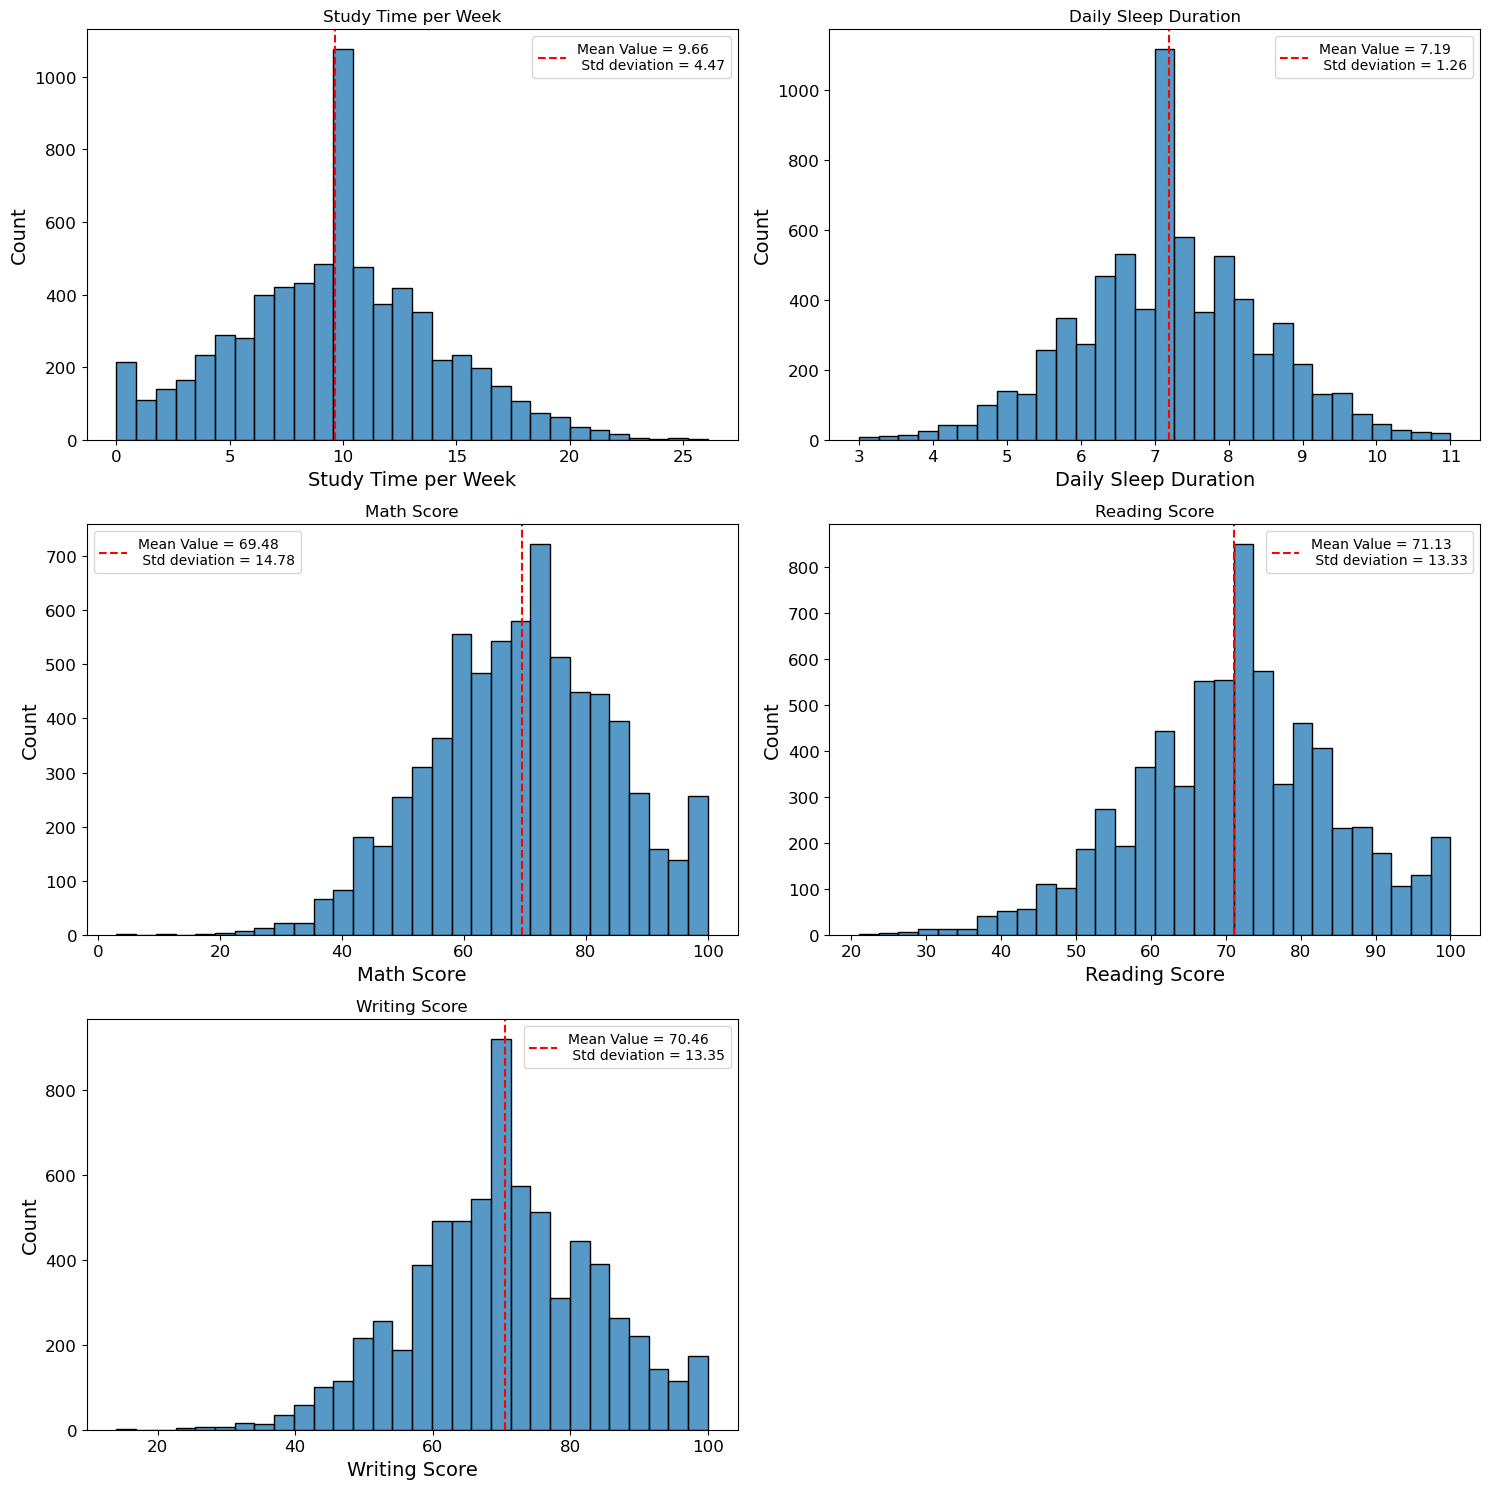

In [30]:
fig, axes = plt.subplots(3, 2, figsize=(15, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_col.columns):
    mean_val = clean_student_performance[col].mean() 
    std_val = clean_student_performance[col].std()
    sns.histplot(clean_student_performance[col], bins=30, ax = axes[i])
    axes[i].axvline(x=mean_val, color = 'r', linestyle = '--', label = f"Mean Value = {mean_val:.2f} \n Std deviation = {std_val:.2f}")
    axes[i].legend()
    axes[i].set_title(col)

# remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()
plt.show()


# Training Model

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# predict the average score based on categorial and numerical variables

model_df = student_performance_tr_df.copy()
model_df["num__Avg Score"] = (model_df["num__Math Score"] + model_df["num__Reading Score"] + model_df["num__Writing Score"])/3

# Predictor features
X = model_df.drop(['num__Math Score', 'num__Reading Score', 'num__Writing Score', 'num__Avg Score'], axis = 1)
# Output
y = model_df['num__Avg Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# trainining
model = RandomForestRegressor(n_estimators=1000)
model.fit(X_train, y_train)

#predicting
y_pred = model.predict(X_test)

# evaluate metric
mse = mean_squared_error(y_test, y_pred)
R_sqr = r2_score(y_test, y_pred)
print (f"Mean Square = {mse:.2f}")
print (f"R square metric = {R_sqr:.2f}")




Mean Square = 64.92
R square metric = -0.07


## Improving the trainning 